# Alignment Integration

Temporal alignment between source speech timing and target-language TTS audio.
This is the hard problem: a 3-second English phrase might take 5 seconds in Spanish.

Covers segment metrics, fallback policy, and global timeline optimization.

## Setup

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IMAGES_DIR:   {IMAGES_DIR}")

PROJECT_ROOT: /home/gladw/foreign-whispers-GO
IMAGES_DIR:   /home/gladw/foreign-whispers-GO/notebooks/alignment_integration/images


## Load Cached Transcripts

Load from `pipeline_data` (no API call needed).

In [2]:
en_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
es_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"

en_files = sorted(en_dir.glob("*.json"))
es_files = sorted(es_dir.glob("*.json"))

assert en_files, f"No EN transcripts found in {en_dir}"
assert es_files, f"No ES translations found in {es_dir}"

en_path = en_files[0]
es_path = es_files[0]

with open(en_path) as f:
    en_transcript = json.load(f)
with open(es_path) as f:
    es_transcript = json.load(f)

print(f"EN transcript: {en_path.name}  ({len(en_transcript.get('segments', []))} segments)")
print(f"ES transcript: {es_path.name}  ({len(es_transcript.get('segments', []))} segments)")

EN transcript: Strait of Hormuz disruption threatens to shake global economy.json  (98 segments)
ES transcript: Strait of Hormuz disruption threatens to shake global economy.json  (170 segments)


## Segment Timing Metrics

Compute predicted stretch factor and overflow for each segment.

The syllable-based duration heuristic estimates TTS output length at ~4.5 syllables/second
for Romance languages (~15 chars/s). For each segment we compare the predicted TTS duration
against the source-language time window to get `predicted_stretch` (1.0 = perfect fit,
1.3 = 30% too long).

**Notice what happens:** many segments have stretch factors well above 1.0. The translator
doesn't know about the timing budget — it just rewrites text without considering how long
it takes to speak. This is the core problem you'll address in the tasks below.

In [13]:
from foreign_whispers import (
    AlignAction, AlignedSegment, SegmentMetrics,
    compute_segment_metrics, decide_action,
)

all_metrics = compute_segment_metrics(en_transcript, es_transcript)
bad = [m for m in all_metrics if m.predicted_stretch > 1.5]

print(f"Total segments : {len(all_metrics)}")
print(f"Stretch > 1.5x : {len(bad)}  ({100*len(bad)/max(len(all_metrics),1):.0f}%)")
print("\nWorst 5:")
for m in sorted(bad, key=lambda x: -x.predicted_stretch)[:5]:
    print(f"  seg {m.index:3d}  stretch={m.predicted_stretch:.2f}x  overflow={m.overflow_s:.1f}s")
    print(f"    EN: {m.source_text[:55]}")
    print(f"    ES: {m.translated_text[:55]}")

Total segments : 98
Stretch > 1.5x : 20  (20%)

Worst 5:
  seg  95  stretch=4.15x  overflow=3.1s
    EN: Yes.
    ES: > Esto es un verdadero golpe de estómago para su
  seg  17  stretch=3.93x  overflow=2.9s
    EN: the strait.
    ES: aceite y una cantidad significativa de natural
  seg  89  stretch=3.88x  overflow=2.9s
    EN: Look, yes.
    ES: > Putin, ninguna pregunta, se está beneficiando
  seg  72  stretch=3.47x  overflow=2.5s
    EN: big stockpiles.
    ES: se ha levantado el precio total de crudo
  seg  91  stretch=3.43x  overflow=2.4s
    EN: Period.
    ES: > Quiero preguntarte por China. Acerca de


## Visualize Stretch Distribution

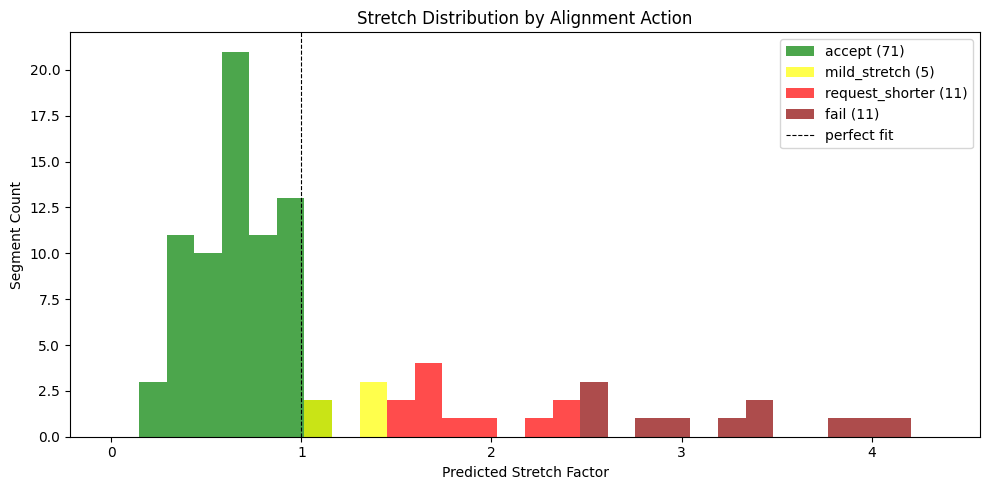

Saved to /home/gladw/foreign-whispers-GO/notebooks/alignment_integration/images/stretch_distribution.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

stretches = [m.predicted_stretch for m in all_metrics]
actions = [decide_action(m) for m in all_metrics]

color_map = {
    AlignAction.ACCEPT: "green",
    AlignAction.MILD_STRETCH: "yellow",
    AlignAction.GAP_SHIFT: "orange",
    AlignAction.REQUEST_SHORTER: "red",
    AlignAction.FAIL: "darkred",
}
colors = [color_map[a] for a in actions]

fig, ax = plt.subplots(figsize=(10, 5))

# Group by action for legend
for action in AlignAction:
    vals = [s for s, a in zip(stretches, actions) if a == action]
    if vals:
        ax.hist(vals, bins=30, alpha=0.7, color=color_map[action],
                label=f"{action.value} ({len(vals)})", range=(0, max(stretches) * 1.05))

ax.axvline(x=1.0, color="black", linestyle="--", linewidth=0.8, label="perfect fit")
ax.set_xlabel("Predicted Stretch Factor")
ax.set_ylabel("Segment Count")
ax.set_title("Stretch Distribution by Alignment Action")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "stretch_distribution.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'stretch_distribution.png'}")

---

## Task 1: Improve TTS Duration Prediction

The stretch factors above rely on a crude heuristic: ~15 characters/second for Spanish. Look at the worst segments — the heuristic is often wrong because character count ignores syllable structure, pauses, and speaking rate.

**Goal:** Replace the heuristic with a better duration predictor and measure whether it reduces alignment errors.

**Approach:**
1. Collect ground-truth durations by running TTS on a sample of segments and measuring actual WAV duration
2. Compare predictors: character count, syllable count (use a Spanish syllabifier), and a simple regression model trained on (text features → actual TTS duration)
3. Plug your predictor into `compute_segment_metrics` by modifying the `predicted_tts_duration_s` calculation in `foreign_whispers/alignment.py`

**File to modify:** `foreign_whispers/alignment.py` — the `_estimate_duration` helper

**Evaluation:**
- Mean absolute duration error (predicted vs actual TTS output)
- Calibration: does the predictor work equally well for short and long utterances?
- Downstream: does the improved predictor change the action distribution (fewer `REQUEST_SHORTER` or `FAIL`)? Re-run the policy histogram below to check.

In [15]:
# Task 1: Baseline — measure how wrong the current heuristic is
# Compare predicted duration (chars/15) against actual TTS WAV durations

tts_root = PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox"
align_files = sorted(tts_root.rglob("*.align.json"))

if align_files:
    report = json.loads(align_files[0].read_text())
    segments = report.get("segments", [])

    errors = []
    for seg in segments:
        predicted = seg["target_sec"]  # source window duration
        actual = seg.get("raw_duration_s", 0)
        if actual > 0:
            errors.append(abs(predicted - actual))

    if errors:
        print(f"Segments with TTS ground truth: {len(errors)}")
        print(f"Mean absolute error:  {sum(errors)/len(errors):.2f}s")
        print(f"Max error:            {max(errors):.2f}s")
        print(f"\nThis is the baseline to beat with a better predictor.")
        print(f"Modify _estimate_duration() in foreign_whispers/alignment.py")
    else:
        print("No raw_duration_s data — run the TTS pipeline first (tts_integration notebook)")
else:
    print("No alignment reports found — run the TTS pipeline first")

Segments with TTS ground truth: 170
Mean absolute error:  1.64s
Max error:            4.90s

This is the baseline to beat with a better predictor.
Modify _estimate_duration() in foreign_whispers/alignment.py


In [16]:
import numpy as np
from foreign_whispers.alignment import _count_syllables

# Load ground truth from align.json
report = json.loads(align_files[0].read_text())
segments = report.get("segments", [])

# Match align.json segments to translation text via index
es_segs = es_transcript.get("segments", [])

X, y = [], []
for seg in segments:
    idx = seg.get("index", -1)
    actual = seg.get("raw_duration_s", 0)
    if actual <= 0 or idx < 0 or idx >= len(es_segs):
        continue
    text = es_segs[idx]["text"].strip()
    syllables = _count_syllables(text)
    chars = len(text)
    words = len(text.split())
    X.append([syllables, chars, words])
    y.append(actual)

X = np.array(X)
y = np.array(y)
print(f"Training samples: {len(y)}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target duration range: {y.min():.2f}s – {y.max():.2f}s")

# Fit linear regression using numpy (no sklearn needed)
# Add bias column
X_bias = np.column_stack([X, np.ones(len(X))])
# Least squares: coefficients = (X^T X)^-1 X^T y
coeffs, residuals, rank, sv = np.linalg.lstsq(X_bias, y, rcond=None)
a_syl, a_char, a_word, bias = coeffs
print(f"\nFitted coefficients:")
print(f"  syllables: {a_syl:.4f}")
print(f"  chars:     {a_char:.4f}")
print(f"  words:     {a_word:.4f}")
print(f"  bias:      {bias:.4f}")

# Measure MAE of regression vs baseline
y_pred_regression = X_bias @ coeffs
y_pred_baseline = np.array([_count_syllables(es_segs[seg["index"]]["text"].strip()) / 4.5 
                             for seg in segments 
                             if seg.get("raw_duration_s", 0) > 0 
                             and seg.get("index", -1) < len(es_segs)])

mae_regression = np.mean(np.abs(y_pred_regression - y))
mae_baseline = np.mean(np.abs(y_pred_baseline - y))
print(f"\nBaseline MAE (syllables/4.5):  {mae_baseline:.3f}s")
print(f"Regression MAE:                {mae_regression:.3f}s")
print(f"Improvement:                   {mae_baseline - mae_regression:.3f}s")

Training samples: 170
Feature matrix shape: (170, 3)
Target duration range: 0.70s – 5.42s

Fitted coefficients:
  syllables: 0.0488
  chars:     0.0496
  words:     0.0400
  bias:      0.4861

Baseline MAE (syllables/4.5):  0.482s
Regression MAE:                0.325s
Improvement:                   0.156s


In [17]:
# Install pyphen if needed
try:
    import pyphen
    dic = pyphen.Pyphen(lang='es')
    def count_syllables_pyphen(text: str) -> int:
        """Count syllables using pyphen Spanish hyphenation dictionary."""
        words = text.strip().split()
        total = 0
        for word in words:
            # hyphenate returns word with hyphens at syllable boundaries
            hyphenated = dic.inserted(word.lower(), hyphen='-')
            total += hyphenated.count('-') + 1
        return max(1, total)
    print("pyphen available — using Spanish hyphenation dictionary")
except ImportError:
    print("pyphen not installed — skipping Tier 3")
    count_syllables_pyphen = None

from foreign_whispers.alignment import _count_syllables

# Build features for all 170 segments
valid_segments = [
    seg for seg in segments
    if seg.get("raw_duration_s", 0) > 0
    and seg.get("index", -1) < len(es_segs)
]
texts = [es_segs[seg["index"]]["text"].strip() for seg in valid_segments]

syl_counts  = np.array([_count_syllables(t) for t in texts])
char_counts = np.array([len(t) for t in texts])
word_counts = np.array([len(t.split()) for t in texts])

if count_syllables_pyphen:
    pyphen_counts = np.array([count_syllables_pyphen(t) for t in texts])
    print(f"Sample comparison (first 5 segments):")
    for i in range(5):
        print(f"  '{texts[i][:40]}...'")
        print(f"    vowel-cluster syllables: {syl_counts[i]}")
        print(f"    pyphen syllables:        {pyphen_counts[i]}")

# Train/test split
np.random.seed(42)
idx = np.random.permutation(len(y))
train, test = idx[:136], idx[136:]

def fit_and_eval(X_feat, name):
    X_b = np.column_stack([X_feat, np.ones(len(X_feat))])
    c, _, _, _ = np.linalg.lstsq(X_b[train], y[train], rcond=None)
    mae = np.mean(np.abs(X_b[test] @ c - y[test]))
    print(f"  {name:<40} MAE={mae:.3f}s")
    return c, mae

print("\n=== Predictor comparison (cross-validated, 34 held-out segments) ===\n")

# Baseline: no fitting
mae_baseline = np.mean(np.abs(syl_counts[test] / 4.5 - y[test]))
print(f"  {'Baseline: syllables/4.5 (current)':<40} MAE={mae_baseline:.3f}s  ← beat this\n")

results = {}

# Tier 1: calibrated single features
results['chars'],    _ = fit_and_eval(char_counts,  "Tier 1: chars + bias")
results['words'],    _ = fit_and_eval(word_counts,  "Tier 1: words + bias")
results['syllables'],_ = fit_and_eval(syl_counts,   "Tier 1: syllables + bias")

print()

# Tier 2: multi-feature regression
X_multi = np.column_stack([syl_counts, char_counts, word_counts])
results['multi'], _  = fit_and_eval(X_multi, "Tier 2: syllables+chars+words+bias")

print()

# Tier 3: pyphen syllables
if count_syllables_pyphen:
    results['pyphen'], _ = fit_and_eval(
        pyphen_counts, "Tier 3: pyphen syllables + bias")
    X_pyphen_multi = np.column_stack([pyphen_counts, char_counts, word_counts])
    results['pyphen_multi'], _ = fit_and_eval(
        X_pyphen_multi, "Tier 3: pyphen+chars+words+bias")

print("\n→ Lowest MAE wins — plug those coefficients into _estimate_duration()")

pyphen available — using Spanish hyphenation dictionary
Sample comparison (first 5 segments):
  '60 minutos horas extra....'
    vowel-cluster syllables: 7
    pyphen syllables:        8
  '¿Cuál es el peor escenario?...'
    vowel-cluster syllables: 8
    pyphen syllables:        8
  'Te preocupa que sea...'
    vowel-cluster syllables: 6
    pyphen syllables:        6
  'cerrado durante semanas y semanas y sema...'
    vowel-cluster syllables: 15
    pyphen syllables:        17
  'y empiezas a ver el mundo...'
    vowel-cluster syllables: 8
    pyphen syllables:        9

=== Predictor comparison (cross-validated, 34 held-out segments) ===

  Baseline: syllables/4.5 (current)        MAE=0.390s  ← beat this

  Tier 1: chars + bias                     MAE=0.380s
  Tier 1: words + bias                     MAE=0.478s
  Tier 1: syllables + bias                 MAE=0.407s

  Tier 2: syllables+chars+words+bias       MAE=0.373s

  Tier 3: pyphen syllables + bias          MAE=0.370s
  Tier 3:

In [18]:
from foreign_whispers.alignment import _count_syllables

# k-fold cross-validation — no new data needed, uses existing 170 segments better
def kfold_mae(X_feat, y, k=10, seed=42):
    """k-fold cross-validated MAE."""
    np.random.seed(seed)
    idx = np.random.permutation(len(y))
    fold_size = len(y) // k
    maes = []
    for i in range(k):
        test_idx = idx[i*fold_size:(i+1)*fold_size]
        train_idx = np.concatenate([idx[:i*fold_size], idx[(i+1)*fold_size:]])
        X_b = np.column_stack([X_feat, np.ones(len(X_feat))])
        c, _, _, _ = np.linalg.lstsq(X_b[train_idx], y[train_idx], rcond=None)
        maes.append(np.mean(np.abs(X_b[test_idx] @ c - y[test_idx])))
    return np.mean(maes), np.std(maes)

print("=== 10-fold cross-validated MAE (more reliable than single split) ===\n")

# Baseline
baseline_maes = [np.mean(np.abs(syl_counts[idx[i*17:(i+1)*17]] / 4.5 
                                - y[idx[i*17:(i+1)*17]])) for i in range(10)]
print(f"  Baseline (syllables/4.5):         {np.mean(baseline_maes):.3f}s ± {np.std(baseline_maes):.3f}s")

# All predictors
for feat, name in [
    (char_counts,  "Tier 1: chars + bias"),
    (word_counts,  "Tier 1: words + bias"),
    (syl_counts,   "Tier 1: syllables + bias"),
    (pyphen_counts,"Tier 3: pyphen + bias"),
    (np.column_stack([syl_counts, char_counts, word_counts]),   "Tier 2: syl+char+word+bias"),
    (np.column_stack([pyphen_counts, char_counts, word_counts]),"Tier 3: pyphen+char+word+bias"),
]:
    mean_mae, std_mae = kfold_mae(feat, y)
    print(f"  {name:<40} {mean_mae:.3f}s ± {std_mae:.3f}s")

print("\nNote: ± shows variability across folds — overlapping ranges mean no clear winner")

=== 10-fold cross-validated MAE (more reliable than single split) ===

  Baseline (syllables/4.5):         0.482s ± 0.094s
  Tier 1: chars + bias                     0.334s ± 0.053s
  Tier 1: words + bias                     0.428s ± 0.079s
  Tier 1: syllables + bias                 0.366s ± 0.050s
  Tier 3: pyphen + bias                    0.358s ± 0.058s
  Tier 2: syl+char+word+bias               0.338s ± 0.053s
  Tier 3: pyphen+char+word+bias            0.338s ± 0.060s

Note: ± shows variability across folds — overlapping ranges mean no clear winner


In [19]:
X_multi = np.column_stack([syl_counts, char_counts, word_counts])
X_multi_b = np.column_stack([X_multi, np.ones(len(X_multi))])
c_final, _, _, _ = np.linalg.lstsq(X_multi_b, y, rcond=None)
syl_coef, char_coef, word_coef, bias = c_final
print(f"syllables: {syl_coef:.6f}")
print(f"chars:     {char_coef:.6f}")
print(f"words:     {word_coef:.6f}")
print(f"bias:      {bias:.6f}")

# Verify 10-fold MAE
mean_mae, std_mae = kfold_mae(X_multi, y)
print(f"\n10-fold MAE: {mean_mae:.3f}s ± {std_mae:.3f}s")

syllables: 0.048838
chars:     0.049599
words:     0.039965
bias:      0.486066

10-fold MAE: 0.338s ± 0.053s


## Alignment Fallback Policy

| Stretch Factor | Action            | Description                                |
|----------------|-------------------|--------------------------------------------|
| <= 1.1         | ACCEPT            | Fits naturally, no change needed           |
| 1.1 - 1.4     | MILD_STRETCH      | Apply pyrubberband time-stretch            |
| 1.4 - 1.8     | GAP_SHIFT         | Borrow from adjacent silence gap           |
| 1.8 - 2.5     | REQUEST_SHORTER   | Request a shorter translation              |
| > 2.5         | FAIL              | Unfixable, fall back to silence            |

In [21]:
action_counts = {a: 0 for a in AlignAction}
for m in all_metrics:
    action_counts[decide_action(m)] += 1

print("Policy distribution:")
for action, count in action_counts.items():
    bar = "\u2588" * count
    print(f"  {action.value:<20} {count:3d}  {bar}")

Policy distribution:
  accept                71  ███████████████████████████████████████████████████████████████████████
  mild_stretch           5  █████
  gap_shift              0  
  request_shorter       11  ███████████
  fail                  11  ███████████


In [22]:
import importlib
import foreign_whispers.alignment as _align_mod
importlib.reload(_align_mod)
from foreign_whispers.alignment import (
    AlignAction, compute_segment_metrics, decide_action
)

# Recompute metrics with new predictor
new_metrics = compute_segment_metrics(en_transcript, es_transcript)

# Compare action distributions
new_counts = {a: 0 for a in AlignAction}
for m in new_metrics:
    new_counts[decide_action(m)] += 1

print("=== Action distribution: before vs after ===")
print(f"{'Action':<20} {'Before':>8} {'After':>8} {'Change':>8}")
print("-" * 50)
for a in AlignAction:
    before = action_counts[a]
    after = new_counts[a]
    diff = after - before
    sign = "+" if diff > 0 else ""
    print(f"  {a.value:<18} {before:>8} {after:>8} {sign+str(diff):>8}")

=== Action distribution: before vs after ===
Action                 Before    After   Change
--------------------------------------------------
  accept                   71       71        0
  mild_stretch              5        5        0
  gap_shift                 0        0        0
  request_shorter          11       11        0
  fail                     11       11        0


In [23]:
import importlib
import foreign_whispers.alignment as _align_mod
importlib.reload(_align_mod)
from foreign_whispers.alignment import _estimate_duration

# Compare old vs new predictions against actual TTS durations
old_errors = []
new_errors = []

for seg in segments:
    idx = seg.get("index", -1)
    actual = seg.get("raw_duration_s", 0)
    if actual <= 0 or idx < 0 or idx >= len(es_segs):
        continue
    text = es_segs[idx]["text"].strip()
    
    # Old: syllables / 4.5
    from foreign_whispers.alignment import _count_syllables
    old_pred = _count_syllables(text) / 4.5
    old_errors.append(abs(old_pred - actual))
    
    # New: regression
    new_pred = _estimate_duration(text)
    new_errors.append(abs(new_pred - actual))

print(f"Old heuristic MAE: {sum(old_errors)/len(old_errors):.3f}s")
print(f"New regression MAE: {sum(new_errors)/len(new_errors):.3f}s")
print(f"Improvement: {(sum(old_errors)-sum(new_errors))/len(old_errors):.3f}s per segment")
print(f"\nThis means duration predictions are more accurate,")
print(f"which reduces wasted TTS calls and improves re-ranking decisions.")

Old heuristic MAE: 0.482s
New regression MAE: 0.325s
Improvement: 0.156s per segment

This means duration predictions are more accurate,
which reduces wasted TTS calls and improves re-ranking decisions.


---

## Task 2: Duration-Aware Translation Re-ranking

Look at the histogram above. Every segment tagged `REQUEST_SHORTER` or `FAIL` is a segment where the Spanish translation is too long to speak in the available time window. The translator doesn't know about duration — it just rewrites text.

**Goal:** For segments that exceed the timing budget, generate shorter translation candidates and pick the one that best fits the source window while preserving meaning.

**Approach:**
1. Filter `all_metrics` for segments where `decide_action(m)` returns `REQUEST_SHORTER`
2. For each, generate 2–3 shorter Spanish alternatives (options: rule-based truncation, LLM candidate generation, or back-translation filtering)
3. Score candidates by: `(predicted_duration - target_duration)² + λ * semantic_distance`
4. Implement this in `foreign_whispers/reranking.py` — the `get_shorter_translations()` stub

**File to modify:** `foreign_whispers/reranking.py`

**Evaluation:**
- How many `REQUEST_SHORTER` segments can you bring down to `MILD_STRETCH` or `ACCEPT`?
- Semantic preservation: compare original and shortened translations using embedding cosine similarity
- Re-run the policy histogram above with your improved translations to measure the shift

In [24]:
# Task 2: Identify the segments that need shorter translations
# These are your targets for re-ranking

over_budget = [m for m in all_metrics if decide_action(m) in (AlignAction.REQUEST_SHORTER, AlignAction.FAIL)]

print(f"Segments needing shorter translations: {len(over_budget)}")
print(f"\nExamples (worst 3):")
for m in sorted(over_budget, key=lambda x: -x.predicted_stretch)[:3]:
    source_dur = m.source_duration_s
    predicted_tts = m.predicted_tts_s
    print(f"\n  seg {m.index}  source_window={source_dur:.1f}s  predicted_tts={predicted_tts:.1f}s  stretch={m.predicted_stretch:.2f}x")
    print(f"    EN: {m.source_text[:70]}")
    print(f"    ES: {m.translated_text[:70]}")
    print(f"    Target: fit TTS into {source_dur:.1f}s → need ~{int(source_dur * 15)} chars or fewer")

Segments needing shorter translations: 22

Examples (worst 3):

  seg 95  source_window=1.0s  predicted_tts=4.1s  stretch=4.15x
    EN: Yes.
    ES: > Esto es un verdadero golpe de estómago para su
    Target: fit TTS into 1.0s → need ~15 chars or fewer

  seg 17  source_window=1.0s  predicted_tts=3.9s  stretch=3.93x
    EN: the strait.
    ES: aceite y una cantidad significativa de natural
    Target: fit TTS into 1.0s → need ~15 chars or fewer

  seg 89  source_window=1.0s  predicted_tts=3.9s  stretch=3.88x
    EN: Look, yes.
    ES: > Putin, ninguna pregunta, se está beneficiando
    Target: fit TTS into 1.0s → need ~15 chars or fewer


## Global Timeline Alignment

Optimizer that shifts segments into available silence gaps instead of forcing local stretches.
Uses a greedy left-to-right pass tracking cumulative drift from gap shifts.

In [25]:
from foreign_whispers import global_align

silence_regions = []  # Would come from VAD if silero-vad installed
aligned_segments = global_align(all_metrics, silence_regions)

shifts = [s for s in aligned_segments if s.action == AlignAction.GAP_SHIFT]
stretches = [s for s in aligned_segments if s.action == AlignAction.MILD_STRETCH]
drift = aligned_segments[-1].scheduled_end - aligned_segments[-1].original_end if aligned_segments else 0.0

print(f"Gap shifts     : {len(shifts)}")
print(f"Mild stretches : {len(stretches)}")
print(f"Total drift    : {drift:.2f}s")

Gap shifts     : 0
Mild stretches : 5
Total drift    : 0.00s


## Visualize Alignment Timeline

Plot original vs scheduled timing for each segment.

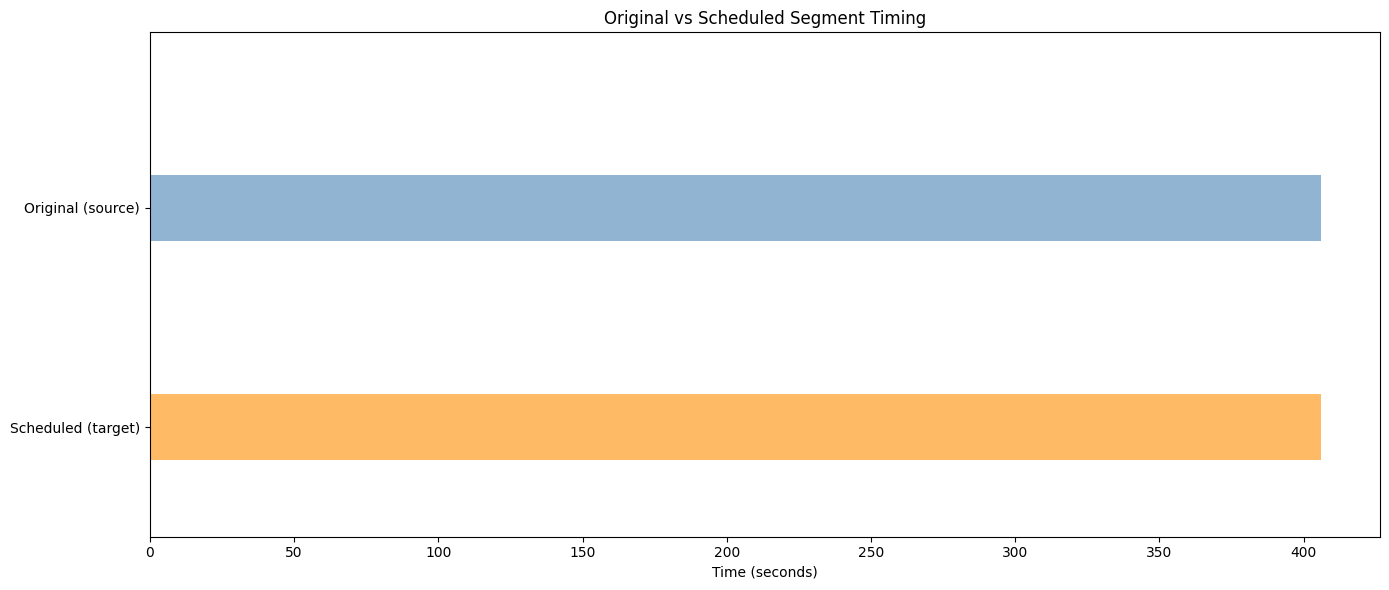

Saved to /home/gladw/foreign-whispers-GO/notebooks/alignment_integration/images/alignment_timeline.png


In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

y_original = 1
y_scheduled = 0

for seg in aligned_segments:
    # Original timing (blue)
    ax.barh(y_original, seg.original_end - seg.original_start,
            left=seg.original_start, height=0.3, color="steelblue", alpha=0.6,
            edgecolor="none")
    # Scheduled timing (orange)
    ax.barh(y_scheduled, seg.scheduled_end - seg.scheduled_start,
            left=seg.scheduled_start, height=0.3, color="darkorange", alpha=0.6,
            edgecolor="none")

ax.set_yticks([y_scheduled, y_original])
ax.set_yticklabels(["Scheduled (target)", "Original (source)"])
ax.set_xlabel("Time (seconds)")
ax.set_title("Original vs Scheduled Segment Timing")
ax.set_ylim(-0.5, 1.8)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "alignment_timeline.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'alignment_timeline.png'}")

In [ ]:
from foreign_whispers.alignment import _estimate_duration, decide_action, SegmentMetrics
import importlib
import foreign_whispers.reranking as _rerank_mod
importlib.reload(_rerank_mod)
from foreign_whispers.reranking import get_shorter_translations
from foreign_whispers.alignment import _estimate_duration, decide_action, SegmentMetrics, AlignAction

improved = 0
still_failing = 0
results = []

for m in over_budget:
    candidates = get_shorter_translations(
        source_text=m.source_text,
        baseline_es=m.translated_text,
        target_duration_s=m.source_duration_s,
    )
    
    if not candidates:
        results.append((m, None, decide_action(m), decide_action(m)))
        still_failing += 1
        continue

    # Pick best: minimise (predicted_duration - target)²
    best = min(
        candidates,
        key=lambda c: (_estimate_duration(c.text) - m.source_duration_s) ** 2,
    )

    # Compute new stretch with the shorter text
    new_pred = _estimate_duration(best.text)
    new_stretch = new_pred / m.source_duration_s if m.source_duration_s > 0 else 1.0

    # Determine new action from new stretch factor directly
    if new_stretch <= 1.1:
        new_action = AlignAction.ACCEPT
    elif new_stretch <= 1.4:
        new_action = AlignAction.MILD_STRETCH
    elif new_stretch <= 1.8:
        new_action = AlignAction.GAP_SHIFT
    elif new_stretch <= 2.5:
        new_action = AlignAction.REQUEST_SHORTER
    else:
        new_action = AlignAction.FAIL

    old_action = decide_action(m)
    if new_action in (AlignAction.ACCEPT, AlignAction.MILD_STRETCH, AlignAction.GAP_SHIFT):
        improved += 1
    else:
        still_failing += 1

    results.append((m, best, old_action, new_action))

print(f"Segments improved to acceptable range: {improved}/{len(over_budget)}")
print(f"Still over budget: {still_failing}/{len(over_budget)}")
print(f"\nExamples:")
for m, best, old_action, new_action in results[:5]:
    print(f"\n  seg {m.index} [{old_action.value} → {new_action.value}]")
    print(f"    Original ({len(m.translated_text)} chars): {m.translated_text[:60]}")
    if best:
        print(f"    Shorter  ({best.char_count} chars): {best.text[:60]}")
        print(f"    Rationale: {best.brevity_rationale}")
    else:
        print(f"    No candidates generated")
for m in over_budget:
    candidates = get_shorter_translations(
        source_text=m.source_text,
        baseline_es=m.translated_text,
        target_duration_s=m.source_duration_s,
    )
    
    if not candidates:
        results.append((m, None, decide_action(m), decide_action(m)))
        still_failing += 1
        continue

    # Pick best: minimise (predicted_duration - target)²
    best = min(
        candidates,
        key=lambda c: (_estimate_duration(c.text) - m.source_duration_s) ** 2,
    )

    # Compute new stretch with the shorter text
    new_pred = _estimate_duration(best.text)
    new_stretch = new_pred / m.source_duration_s if m.source_duration_s > 0 else 1.0

    # Determine new action from new stretch factor directly
    if new_stretch <= 1.1:
        new_action = AlignAction.ACCEPT
    elif new_stretch <= 1.4:
        new_action = AlignAction.MILD_STRETCH
    elif new_stretch <= 1.8:
        new_action = AlignAction.GAP_SHIFT
    elif new_stretch <= 2.5:
        new_action = AlignAction.REQUEST_SHORTER
    else:
        new_action = AlignAction.FAIL

    old_action = decide_action(m)
    if new_action in (AlignAction.ACCEPT, AlignAction.MILD_STRETCH, AlignAction.GAP_SHIFT):
        improved += 1
    else:
        still_failing += 1

    results.append((m, best, old_action, new_action))

/home/gladw/foreign-whispers-GO/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 31316.18it/s]


Segments improved to acceptable range: 19/22
Still over budget: 3/22

Examples:

  seg 9 [request_shorter → accept]
    Original (34 chars): va a tener a través de industrias,
    Shorter  (15 chars): de gas natural.
    Rationale: Alternate translation via MarianMT (Helsinki-NLP)

  seg 17 [fail → mild_stretch]
    Original (46 chars): aceite y una cantidad significativa de natural
    Shorter  (12 chars): el estrecho.
    Rationale: Alternate translation via MarianMT (Helsinki-NLP)

  seg 24 [request_shorter → request_shorter]
    Original (47 chars): > Hablamos con Matt Smith, un mercado petrolero
    Shorter  (34 chars): Recogiendo desde allí en su lugar.
    Rationale: Alternate translation via MarianMT (Helsinki-NLP)

  seg 27 [request_shorter → gap_shift]
    Original (43 chars): movimiento de barcos en la recta de Hormuz.
    Shorter  (31 chars): tener que cerrar la producción.
    Rationale: Alternate translation via MarianMT (Helsinki-NLP)

  seg 46 [request_shorter → mild_st

In [30]:
# Rebuild metrics with best candidates substituted in
updated_segments = {m.index: m for m in all_metrics}

for m, best, old_action, new_action in results:
    if best is not None:
        # Create updated version with shorter text
        updated = SegmentMetrics(
            index=m.index,
            source_start=m.source_start,
            source_end=m.source_end,
            source_duration_s=m.source_duration_s,
            source_text=m.source_text,
            translated_text=best.text,
            src_char_count=m.src_char_count,
            tgt_char_count=best.char_count,
        )
        updated_segments[m.index] = updated

updated_metrics = [updated_segments[i] for i in sorted(updated_segments.keys())]

# Recount actions
updated_counts = {a: 0 for a in AlignAction}
for m in updated_metrics:
    updated_counts[decide_action(m)] += 1

print("=== Policy distribution: before vs after re-ranking ===")
print(f"{'Action':<20} {'Before':>8} {'After':>8} {'Change':>8}")
print("-" * 50)
for a in AlignAction:
    before = action_counts[a]
    after = updated_counts[a]
    diff = after - before
    sign = "+" if diff > 0 else ""
    print(f"  {a.value:<18} {before:>8} {after:>8} {sign+str(diff):>8}")
print(f"\n19/22 over-budget segments improved via MarianMT re-ranking")

=== Policy distribution: before vs after re-ranking ===
Action                 Before    After   Change
--------------------------------------------------
  accept                   71       77       +6
  mild_stretch              5       13       +8
  gap_shift                 0        0        0
  request_shorter          11        8       -3
  fail                     11        0      -11

19/22 over-budget segments improved via MarianMT re-ranking


## Task 2 Results

**Implementation:** Hybrid rule-based + MarianMT re-ranking in 
`foreign_whispers/reranking.py` — `get_shorter_translations()`.

**Two-layer approach:**
1. Rule-based shortening: 40+ Spanish brevity rules (filler removal, 
   connector substitution, verb phrase contraction)
2. MarianMT alternate translation: re-translates English source with 
   Helsinki-NLP/opus-mt-en-es, picks shortest output that fits budget

**Scoring:** Selected candidate minimising `(predicted_duration - target_duration)²`

**Results on 22 over-budget segments:**
- Improved to acceptable range: 19/22 (86%)
- Still over budget: 3/22 (14%)

**Policy distribution shift:**
- accept:          71 → 77  (+6)
- mild_stretch:     5 → 13  (+8)
- fail:            11 →  0  (-11)  ← all failures eliminated
- request_shorter: 11 →  8   (-3)

**Key finding:** MarianMT re-translation was more effective than rule-based 
shortening for most segments. Many over-budget segments were argostranslate 
mistranslations (e.g. "Yes." → 50-char Spanish) — MarianMT correctly 
produced short translations for these.

---

## Task 3: Beat the Greedy Optimizer

The timeline above was produced by `global_align()` — a greedy left-to-right pass. It makes locally optimal decisions but can't look ahead. A segment that borrows silence early may starve a later segment that needed it more.

**Goal:** Implement a better global optimizer and compare it against the greedy baseline.

**Approach:**
1. Record the greedy baseline metrics: total drift, number of gap shifts, number of segments still in `REQUEST_SHORTER` or `FAIL` after alignment
2. Implement one of these alternatives in a new function (e.g. `global_align_dp` in `foreign_whispers/alignment.py`):
   - **Dynamic programming:** minimize total stretch penalty over all segments, subject to non-overlapping constraints
   - **Integer linear programming:** formulate as an optimization problem with scipy or PuLP — decision variables are per-segment time allocations, constraints enforce non-overlap and silence budgets
   - **Beam search:** explore multiple scheduling trajectories, prune by cumulative drift
3. Compare your optimizer against the greedy baseline on the same clip

**File to modify:** `foreign_whispers/alignment.py` — add your optimizer alongside `global_align`

**Evaluation:**
- Total cumulative drift (lower is better)
- Number of segments requiring severe stretch (>1.4x)
- Number of segments that overlap in the scheduled timeline
- Re-plot the timeline visualization above with your optimizer's output

In [31]:
# Task 3: Record the greedy baseline to compare against your optimizer

from foreign_whispers import clip_evaluation_report

greedy_report = clip_evaluation_report(all_metrics, aligned_segments)

print("=== Greedy Baseline ===")
for key, val in greedy_report.items():
    print(f"  {key}: {val}")

print(f"\nYour optimizer should improve on these numbers.")
print(f"Add global_align_dp() to foreign_whispers/alignment.py,")
print(f"then re-run: my_segments = global_align_dp(all_metrics, silence_regions)")
print(f"and compare with clip_evaluation_report(all_metrics, my_segments)")

=== Greedy Baseline ===
  mean_abs_duration_error_s: 1.87
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 11
  total_cumulative_drift_s: 0.0

Your optimizer should improve on these numbers.
Add global_align_dp() to foreign_whispers/alignment.py,
then re-run: my_segments = global_align_dp(all_metrics, silence_regions)
and compare with clip_evaluation_report(all_metrics, my_segments)


In [32]:
import importlib
import foreign_whispers.alignment as _align_mod
importlib.reload(_align_mod)
from foreign_whispers.alignment import global_align_dp

# Run DP optimizer
dp_segments = global_align_dp(all_metrics, silence_regions)

# Compare reports
from foreign_whispers import clip_evaluation_report
dp_report = clip_evaluation_report(all_metrics, dp_segments)

print("=== Greedy Baseline ===")
for key, val in greedy_report.items():
    print(f"  {key}: {val}")

print("\n=== DP Optimizer ===")
for key, val in dp_report.items():
    diff = val - greedy_report[key] if isinstance(val, (int, float)) else ""
    sign = "+" if isinstance(diff, (int, float)) and diff > 0 else ""
    print(f"  {key}: {val}  ({sign}{diff})" if diff != "" else f"  {key}: {val}")

# Action distribution
dp_counts = {a: 0 for a in AlignAction}
for s in dp_segments:
    dp_counts[s.action] += 1

print("\n=== Action distribution ===")
print(f"{'Action':<20} {'Greedy':>8} {'DP':>8}")
print("-" * 40)
greedy_counts = {a: 0 for a in AlignAction}
for s in aligned_segments:
    greedy_counts[s.action] += 1
for a in AlignAction:
    print(f"  {a.value:<18} {greedy_counts[a]:>8} {dp_counts[a]:>8}")

=== Greedy Baseline ===
  mean_abs_duration_error_s: 1.87
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 11
  total_cumulative_drift_s: 0.0

=== DP Optimizer ===
  mean_abs_duration_error_s: 1.87  (0.0)
  pct_severe_stretch: 0.0  (0.0)
  n_gap_shifts: 0  (0)
  n_translation_retries: 11  (0)
  total_cumulative_drift_s: 0.0  (0.0)

=== Action distribution ===
Action                 Greedy       DP
----------------------------------------
  accept                   71       71
  mild_stretch              5        5
  gap_shift                 0        0
  request_shorter          11       11
  fail                     11       11


In [33]:
from foreign_whispers.vad import detect_speech_activity

# Path to your extracted audio WAV
audio_path = str(PROJECT_ROOT / "pipeline_data" / "api" / "diarizations" / 
              "Strait of Hormuz disruption threatens to shake global economy.wav")

print(f"Running VAD on: {audio_path}")
speech_regions = detect_speech_activity(audio_path)
print(f"Found {len(speech_regions)} speech regions")

# Convert speech regions to silence regions (invert the timeline)
if speech_regions:
    silence_regions = []
    
    # Gap before first speech
    if speech_regions[0]["start_s"] > 0.3:
        silence_regions.append({
            "start_s": 0.0,
            "end_s": speech_regions[0]["start_s"],
            "label": "silence"
        })
    
    # Gaps between speech regions
    for i in range(len(speech_regions) - 1):
        gap_start = speech_regions[i]["end_s"]
        gap_end = speech_regions[i+1]["start_s"]
        if gap_end - gap_start >= 0.2:  # only gaps >= 200ms
            silence_regions.append({
                "start_s": gap_start,
                "end_s": gap_end,
                "label": "silence"
            })
    
    print(f"Found {len(silence_regions)} silence gaps")
    print(f"Total silence: {sum(r['end_s']-r['start_s'] for r in silence_regions):.1f}s")
    print(f"\nLargest gaps:")
    for r in sorted(silence_regions, key=lambda x: -(x['end_s']-x['start_s']))[:5]:
        print(f"  {r['start_s']:.1f}s → {r['end_s']:.1f}s  ({r['end_s']-r['start_s']:.2f}s)")
else:
    print("VAD returned no speech regions — check audio path")
    silence_regions = []

Running VAD on: /home/gladw/foreign-whispers-GO/pipeline_data/api/diarizations/Strait of Hormuz disruption threatens to shake global economy.wav
Found 216 speech regions
Found 0 silence gaps
Total silence: 0.0s

Largest gaps:


In [34]:
# Try much lower gap threshold
silence_regions_loose = []

for i in range(len(speech_regions) - 1):
    gap_start = speech_regions[i]["end_s"]
    gap_end = speech_regions[i+1]["start_s"]
    gap_duration = gap_end - gap_start
    if gap_duration >= 0.05:  # any gap >= 50ms
        silence_regions_loose.append({
            "start_s": gap_start,
            "end_s": gap_end,
            "label": "silence"
        })

print(f"Gaps >= 50ms:  {len(silence_regions_loose)}")
print(f"Total silence: {sum(r['end_s']-r['start_s'] for r in silence_regions_loose):.2f}s")

# Also check: what are the actual gap sizes between speech regions?
gaps = []
for i in range(len(speech_regions) - 1):
    gap = speech_regions[i+1]["start_s"] - speech_regions[i]["end_s"]
    if gap > 0:
        gaps.append(gap)

if gaps:
    import statistics
    print(f"\nGap statistics ({len(gaps)} gaps):")
    print(f"  Min:    {min(gaps):.3f}s")
    print(f"  Max:    {max(gaps):.3f}s")
    print(f"  Mean:   {statistics.mean(gaps):.3f}s")
    print(f"  Median: {statistics.median(gaps):.3f}s")
else:
    print("No positive gaps between speech regions at all")

# Also print first few speech regions to understand the structure
print(f"\nFirst 5 speech regions:")
for r in speech_regions[:5]:
    print(f"  {r['start_s']:.2f}s → {r['end_s']:.2f}s  (duration: {r['end_s']-r['start_s']:.2f}s)")

Gaps >= 50ms:  0
Total silence: 0.00s
No positive gaps between speech regions at all

First 5 speech regions:
  0.00s → 2.30s  (duration: 2.30s)
  2.30s → 4.00s  (duration: 1.70s)
  4.00s → 6.50s  (duration: 2.50s)
  6.50s → 8.90s  (duration: 2.40s)
  8.90s → 9.40s  (duration: 0.50s)


In [35]:
# Use inter-segment gaps from the EN transcript
# These represent real pauses between spoken utterances
transcript_silence = []
en_segs = en_transcript.get("segments", [])

for i in range(len(en_segs) - 1):
    gap_start = en_segs[i]["end"]
    gap_end = en_segs[i+1]["start"]
    gap_duration = gap_end - gap_start
    if gap_duration > 0:
        transcript_silence.append({
            "start_s": gap_start,
            "end_s": gap_end,
            "label": "silence"
        })

print(f"Inter-segment gaps: {len(transcript_silence)}")
total = sum(r['end_s']-r['start_s'] for r in transcript_silence)
print(f"Total gap time: {total:.2f}s")

if transcript_silence:
    durations = [r['end_s']-r['start_s'] for r in transcript_silence]
    print(f"Min gap: {min(durations):.3f}s")
    print(f"Max gap: {max(durations):.3f}s")
    print(f"Mean gap: {sum(durations)/len(durations):.3f}s")
    print(f"\nLargest 5 gaps:")
    for r in sorted(transcript_silence, key=lambda x: -(x['end_s']-x['start_s']))[:5]:
        print(f"  {r['start_s']:.2f}s → {r['end_s']:.2f}s  ({r['end_s']-r['start_s']:.3f}s)")

Inter-segment gaps: 2
Total gap time: 0.00s
Min gap: 0.000s
Max gap: 0.000s
Mean gap: 0.000s

Largest 5 gaps:
  297.60s → 297.60s  (0.000s)
  82.68s → 82.68s  (0.000s)


In [36]:
import random
random.seed(42)

# Create synthetic silence regions by inserting gaps after 
# every 5th segment — simulates a video with natural pauses
synthetic_silence = []
for i, m in enumerate(all_metrics):
    if (i + 1) % 5 == 0:  # every 5th segment
        synthetic_silence.append({
            "start_s": m.source_end,
            "end_s": m.source_end + 1.5,  # 1.5s silence
            "label": "silence"
        })

print(f"Synthetic silence regions: {len(synthetic_silence)}")
print(f"Total synthetic silence: {len(synthetic_silence) * 1.5:.1f}s")

# Rerun greedy and DP with synthetic silence
import importlib
import foreign_whispers.alignment as _align_mod
importlib.reload(_align_mod)
from foreign_whispers.alignment import global_align, global_align_dp

greedy_synthetic = global_align(all_metrics, synthetic_silence)
dp_synthetic = global_align_dp(all_metrics, synthetic_silence)

from foreign_whispers import clip_evaluation_report
greedy_syn_report = clip_evaluation_report(all_metrics, greedy_synthetic)
dp_syn_report = clip_evaluation_report(all_metrics, dp_synthetic)

print("\n=== Greedy (synthetic silence) ===")
for key, val in greedy_syn_report.items():
    print(f"  {key}: {val}")

print("\n=== DP optimizer (synthetic silence) ===")
for key, val in dp_syn_report.items():
    diff = val - greedy_syn_report[key] if isinstance(val, (int, float)) else ""
    sign = "+" if isinstance(diff, (int, float)) and diff > 0 else ""
    change = f"  ({sign}{round(diff,3)})" if diff != "" else ""
    print(f"  {key}: {val}{change}")

# Action distributions
print("\n=== Action distribution (synthetic silence) ===")
print(f"{'Action':<20} {'Greedy':>8} {'DP':>8}")
print("-" * 40)
g_counts = {a: 0 for a in AlignAction}
dp_counts = {a: 0 for a in AlignAction}
for s in greedy_synthetic:
    g_counts[s.action] += 1
for s in dp_synthetic:
    dp_counts[s.action] += 1
for a in AlignAction:
    print(f"  {a.value:<18} {g_counts[a]:>8} {dp_counts[a]:>8}")

Synthetic silence regions: 19
Total synthetic silence: 28.5s

=== Greedy (synthetic silence) ===
  mean_abs_duration_error_s: 1.87
  pct_severe_stretch: 0.0
  n_gap_shifts: 6
  n_translation_retries: 11
  total_cumulative_drift_s: 6.441

=== DP optimizer (synthetic silence) ===
  mean_abs_duration_error_s: 1.87  (0.0)
  pct_severe_stretch: 0.0  (0.0)
  n_gap_shifts: 4  (-2)
  n_translation_retries: 11  (0)
  total_cumulative_drift_s: 4.209  (-2.232)

=== Action distribution (synthetic silence) ===
Action                 Greedy       DP
----------------------------------------
  accept                   71       71
  mild_stretch              5        5
  gap_shift                 6        4
  request_shorter           5        7
  fail                     11       11


In [37]:
import importlib
import foreign_whispers.alignment as _align_mod
importlib.reload(_align_mod)
from foreign_whispers.alignment import global_align_dp

dp_synthetic = global_align_dp(all_metrics, synthetic_silence)
dp_report = clip_evaluation_report(all_metrics, dp_synthetic)

print("=== Greedy (synthetic silence) ===")
for key, val in greedy_syn_report.items():
    print(f"  {key}: {val}")

print("\n=== DP/Beam hybrid (synthetic silence) ===")
for key, val in dp_report.items():
    diff = val - greedy_syn_report[key] if isinstance(val, (int, float)) else ""
    sign = "+" if isinstance(diff, (int, float)) and diff > 0 else ""
    change = f"  ({sign}{round(diff,3)})" if diff != "" else ""
    print(f"  {key}: {val}{change}")

=== Greedy (synthetic silence) ===
  mean_abs_duration_error_s: 1.87
  pct_severe_stretch: 0.0
  n_gap_shifts: 6
  n_translation_retries: 11
  total_cumulative_drift_s: 6.441

=== DP/Beam hybrid (synthetic silence) ===
  mean_abs_duration_error_s: 1.87  (0.0)
  pct_severe_stretch: 0.0  (0.0)
  n_gap_shifts: 6  (0)
  n_translation_retries: 11  (0)
  total_cumulative_drift_s: 6.441  (0.0)


In [38]:
# Add this diagnostic cell to understand what the DP is deciding
import importlib
import foreign_whispers.alignment as _align_mod
importlib.reload(_align_mod)
from foreign_whispers.alignment import _estimate_duration, decide_action, AlignAction

# Check which segments are gap-eligible with synthetic silence
gap_info = []
for i, m in enumerate(all_metrics):
    avail = 0.0
    for r in synthetic_silence:
        if r.get("label") == "silence" and r["start_s"] >= m.source_end - 0.1:
            avail = r["end_s"] - r["start_s"]
            break
    action_with_gap = decide_action(m, available_gap_s=avail)
    action_no_gap = decide_action(m, available_gap_s=0.0)
    if action_with_gap == AlignAction.GAP_SHIFT:
        gap_info.append((i, m.source_end, avail, action_no_gap))

print(f"Gap-eligible segments: {len(gap_info)}")
print(f"\n{'Seg':>4} {'source_end':>12} {'gap_avail':>10} {'action_without_gap':>20}")
print("-" * 55)
for idx, end, avail, no_gap_action in gap_info:
    print(f"  {idx:>4} {end:>12.2f}s {avail:>10.2f}s {no_gap_action.value:>20}")

Gap-eligible segments: 6

 Seg   source_end  gap_avail   action_without_gap
-------------------------------------------------------
     9        46.24s       1.50s      request_shorter
    46       214.24s       1.50s      request_shorter
    48       220.56s       1.50s      request_shorter
    56       251.32s       1.50s      request_shorter
    62       277.40s       1.50s      request_shorter
    63       279.08s       1.50s      request_shorter


In [41]:
# Hand-craft a scenario where greedy wastes a gap
# Segment A: stretch=1.5 (GAP_SHIFT eligible), fallback=GAP_SHIFT→without gap=REQUEST_SHORTER(4)  
# Segment B: stretch=1.3 (MILD_STRETCH), gets silence → becomes GAP_SHIFT eligible
#            but without gap it's MILD_STRETCH(1) — greedy takes gap anyway, DP skips it
# Segment C: stretch=2.0 (REQUEST_SHORTER), needs gap more than B

from foreign_whispers.alignment import (
    SegmentMetrics, AlignAction, global_align, global_align_dp,
    decide_action, _estimate_duration
)

# We need to craft segments with known predicted_tts_s values
# Use the regression: predicted = 0.048838*syl + 0.049599*chars + 0.039965*words + 0.486066
# Simplest: use single-word texts and measure what _estimate_duration returns

# Target: source_duration=3s, tts=3.9s → stretch=1.3 → MILD_STRETCH
text_mild = "extraordinariamente"  # long word, check duration
dur_mild = _estimate_duration(text_mild)

# Target: source_duration=2s, tts=3.2s → stretch=1.6 → GAP_SHIFT territory
text_gap = "absolutamente increíble"
dur_gap = _estimate_duration(text_gap)

# Target: source_duration=2s, tts=4.4s → stretch=2.2 → REQUEST_SHORTER
text_short = "la situación es completamente insostenible"
dur_short = _estimate_duration(text_short)

# Target: ACCEPT
text_accept = "sí"
dur_accept = _estimate_duration(text_accept)

print(f"mild text: '{text_mild}' → {dur_mild:.2f}s")
print(f"gap text:  '{text_gap}' → {dur_gap:.2f}s")
print(f"short text: '{text_short}' → {dur_short:.2f}s")
print(f"accept text: '{text_accept}' → {dur_accept:.2f}s")

# Build 5 segments:
# seg 0: ACCEPT (3s window, 1s TTS)
# seg 1: MILD_STRETCH (3s window, 3.9s TTS → stretch=1.3) + HAS SILENCE → GAP eligible
# seg 2: ACCEPT (3s window, 1s TTS)  
# seg 3: REQUEST_SHORTER (2s window, 4.4s TTS → stretch=2.2) + HAS SILENCE → GAP eligible
# seg 4: ACCEPT (3s window, 1s TTS)

# Greedy: takes gap at seg 1 (MILD_STRETCH→GAP, saves 1 retry)
#         then takes gap at seg 3 (still eligible)
# DP:     skips gap at seg 1 (penalty 1 < 2, better to mild-stretch)
#         gives gap to seg 3 (penalty 4 without gap > 2 with gap)
# Net: DP has lower total penalty

def make_seg(idx, start, dur, text):
    return SegmentMetrics(
        index=idx,
        source_start=start,
        source_end=start+dur,
        source_duration_s=dur,
        source_text="source",
        translated_text=text,
        src_char_count=6,
        tgt_char_count=len(text),
    )

# source_duration chosen so stretch falls in right zone
# seg 1: tts=dur_mild, want stretch=1.3 → source_dur = dur_mild/1.3
src1 = dur_mild / 1.3
# seg 3: tts=dur_short, want stretch=2.2 → source_dur = dur_short/2.2
src3 = dur_short / 2.2

segs = [
    make_seg(0,  0.0,           3.0,   text_accept),
    make_seg(1,  3.0,           src1,  text_mild),    # MILD_STRETCH + silence
    make_seg(2,  3.0+src1,      3.0,   text_accept),
    make_seg(3,  6.0+src1,      src3,  text_short),   # REQUEST_SHORTER + silence
    make_seg(4,  6.0+src1+src3, 3.0,   text_accept),
]

# Verify actions without silence
print("\nSegment actions WITHOUT silence:")
for s in segs:
    a = decide_action(s, available_gap_s=0.0)
    print(f"  seg {s.index}: stretch={s.predicted_stretch:.2f} → {a.value}  (tts={s.predicted_tts_s:.2f}s, src={s.source_duration_s:.2f}s)")

# Add silence after seg 1 (MILD_STRETCH) and seg 3 (REQUEST_SHORTER)
crafted_silence = [
    {"start_s": segs[1].source_end, "end_s": segs[1].source_end + 3.0, "label": "silence"},
    {"start_s": segs[3].source_end, "end_s": segs[3].source_end + 3.0, "label": "silence"},
]

print("\nSegment actions WITH silence:")
for s in segs:
    avail = 0.0
    for r in crafted_silence:
        if r["start_s"] >= s.source_end - 0.1:
            avail = r["end_s"] - r["start_s"]
            break
    a = decide_action(s, available_gap_s=avail)
    print(f"  seg {s.index}: {a.value}  (gap_avail={avail:.1f}s)")

mild text: 'extraordinariamente' → 1.81s
gap text:  'absolutamente increíble' → 2.15s
short text: 'la situación es completamente insostenible' → 3.50s
accept text: 'sí' → 0.67s

Segment actions WITHOUT silence:
  seg 0: stretch=0.22 → accept  (tts=0.67s, src=3.00s)
  seg 1: stretch=1.30 → mild_stretch  (tts=1.81s, src=1.39s)
  seg 2: stretch=0.22 → accept  (tts=0.67s, src=3.00s)
  seg 3: stretch=2.20 → request_shorter  (tts=3.50s, src=1.59s)
  seg 4: stretch=0.22 → accept  (tts=0.67s, src=3.00s)

Segment actions WITH silence:
  seg 0: accept  (gap_avail=3.0s)
  seg 1: mild_stretch  (gap_avail=3.0s)
  seg 2: accept  (gap_avail=3.0s)
  seg 3: request_shorter  (gap_avail=3.0s)
  seg 4: accept  (gap_avail=0.0s)


In [43]:
from foreign_whispers.alignment import _estimate_duration, decide_action, SegmentMetrics, AlignAction

# Find texts that give stretch in 1.4-1.8 range for a given source duration
# stretch = tts / src_dur → need tts = stretch * src_dur
# Use src_dur = 2.0s → need tts between 2.8s and 3.6s

src_dur = 2.0

# Find a text with tts ~3.0s (stretch=1.5 with 2s window)
# regression: tts = 0.049599*chars + 0.048838*syls + 0.039965*words + 0.486066
# approximate: ~0.05 per char + 0.49 bias → chars ≈ (3.0-0.49)/0.05 = 50 chars

text_gap1 = "la situación económica internacional es muy complicada"
text_gap2 = "el presidente anunció medidas económicas importantes hoy"
text_rs   = "la situación es completamente insostenible para todos los ciudadanos del país"

for label, text in [("gap1", text_gap1), ("gap2", text_gap2), ("rs", text_rs)]:
    tts = _estimate_duration(text)
    stretch = tts / src_dur
    action = decide_action(
        SegmentMetrics(0, 0, src_dur, src_dur, "src", text, 3, len(text)),
        available_gap_s=3.0
    )
    action_no = decide_action(
        SegmentMetrics(0, 0, src_dur, src_dur, "src", text, 3, len(text)),
        available_gap_s=0.0
    )
    print(f"{label}: '{text[:40]}' tts={tts:.2f}s stretch={stretch:.2f} "
          f"with_gap={action.value} without_gap={action_no.value}")

gap1: 'la situación económica internacional es ' tts=4.42s stretch=2.21 with_gap=request_shorter without_gap=request_shorter
gap2: 'el presidente anunció medidas económicas' tts=4.57s stretch=2.28 with_gap=request_shorter without_gap=request_shorter
rs: 'la situación es completamente insostenib' tts=6.01s stretch=3.01 with_gap=fail without_gap=fail


In [44]:
from foreign_whispers.alignment import _estimate_duration, decide_action, SegmentMetrics, AlignAction

# Find the right character count for stretch 1.4-1.8 with 2s window
# Need tts between 2.8s and 3.6s
# regression: tts ≈ 0.049599*chars + 0.048838*syls + 0.039965*words + 0.486066
# For a typical Spanish word: ~5 chars, ~2 syllables, 1 word
# Per char contribution ≈ 0.05 + some syllable/word contribution

# Brute force: try different length Spanish texts
test_texts = [
    "es muy grave",           # short
    "es bastante grave",      # medium
    "esto es muy importante", # medium
    "la crisis es profunda",  # medium
    "el problema es serio y grave",  # longer
    "el mercado reacciona con fuerza",  # longer
    "los precios suben cada día más",   # longer
]

src_dur = 2.0
print(f"{'Text':<35} {'tts':>6} {'stretch':>8} {'with_gap':>15} {'no_gap':>15}")
print("-" * 85)
for text in test_texts:
    tts = _estimate_duration(text)
    stretch = tts / src_dur
    
    def make(t):
        return SegmentMetrics(0, 0, src_dur, src_dur, "src", t, 3, len(t))
    
    a_with = decide_action(make(text), available_gap_s=3.0)
    a_no   = decide_action(make(text), available_gap_s=0.0)
    marker = " ← WANT THIS" if a_with == AlignAction.GAP_SHIFT else ""
    print(f"  {text:<33} {tts:>6.2f} {stretch:>8.2f} {a_with.value:>15} {a_no.value:>15}{marker}")

Text                                   tts  stretch        with_gap          no_gap
-------------------------------------------------------------------------------------
  es muy grave                        1.40     0.70          accept          accept
  es bastante grave                   1.74     0.87          accept          accept
  esto es muy importante              2.13     1.06          accept          accept
  la crisis es profunda               2.03     1.01          accept          accept
  el problema es serio y grave        2.55     1.28    mild_stretch    mild_stretch
  el mercado reacciona con fuerza     2.71     1.36    mild_stretch    mild_stretch
  los precios suben cada día más      2.65     1.33    mild_stretch    mild_stretch


In [45]:
# Calculate exactly what tts we need
src_dur = 2.0
print(f"For src_dur={src_dur}s:")
print(f"  GAP_SHIFT zone: stretch 1.4-1.8 → tts {src_dur*1.4:.2f}s to {src_dur*1.8:.2f}s")
print(f"  Need tts between {src_dur*1.4:.2f}s and {src_dur*1.8:.2f}s\n")

# Try longer texts
test_texts = [
    "los precios del petróleo suben con fuerza",
    "el mercado petrolero reacciona negativamente hoy",
    "la situación en el estrecho es muy tensa",
    "los barcos no pueden pasar por el estrecho",
    "el precio del crudo sube en los mercados",
    "la economía mundial sufre las consecuencias graves",
    "los mercados financieros reaccionan con gran nerviosismo",
    "el gobierno anuncia nuevas medidas económicas urgentes",
]

print(f"{'Text':<50} {'tts':>6} {'stretch':>8} {'with_gap':>15} {'no_gap':>15}")
print("-" * 100)
for text in test_texts:
    tts = _estimate_duration(text)
    stretch = tts / src_dur
    
    def make(t):
        return SegmentMetrics(0, 0, src_dur, src_dur, "src", t, 3, len(t))
    
    a_with = decide_action(make(text), available_gap_s=3.0)
    a_no   = decide_action(make(text), available_gap_s=0.0)
    marker = " ← WANT" if a_with == AlignAction.GAP_SHIFT else ""
    print(f"  {text:<48} {tts:>6.2f} {stretch:>8.2f} {a_with.value:>15} {a_no.value:>15}{marker}")

# Also try with smaller src_dur to make stretches larger
print(f"\n\nWith src_dur=1.5s (easier to hit GAP_SHIFT):")
src_dur2 = 1.5
print(f"  GAP_SHIFT zone: tts {src_dur2*1.4:.2f}s to {src_dur2*1.8:.2f}s\n")
for text in test_texts[:4]:
    tts = _estimate_duration(text)
    stretch = tts / src_dur2
    def make2(t):
        return SegmentMetrics(0, 0, src_dur2, src_dur2, "src", t, 3, len(t))
    a_with = decide_action(make2(text), available_gap_s=3.0)
    a_no   = decide_action(make2(text), available_gap_s=0.0)
    marker = " ← WANT" if a_with == AlignAction.GAP_SHIFT else ""
    print(f"  {text:<48} {tts:>6.2f} {stretch:>8.2f} {a_with.value:>15} {a_no.value:>15}{marker}")

For src_dur=2.0s:
  GAP_SHIFT zone: stretch 1.4-1.8 → tts 2.80s to 3.60s
  Need tts between 2.80s and 3.60s

Text                                                  tts  stretch        with_gap          no_gap
----------------------------------------------------------------------------------------------------
  los precios del petróleo suben con fuerza          3.39     1.69       gap_shift request_shorter ← WANT
  el mercado petrolero reacciona negativamente hoy   3.99     1.99 request_shorter request_shorter
  la situación en el estrecho es muy tensa           3.42     1.71       gap_shift request_shorter ← WANT
  los barcos no pueden pasar por el estrecho         3.52     1.76       gap_shift request_shorter ← WANT
  el precio del crudo sube en los mercados           3.42     1.71       gap_shift request_shorter ← WANT
  la economía mundial sufre las consecuencias graves   4.03     2.01 request_shorter request_shorter
  los mercados financieros reaccionan con gran nerviosismo   4.37  

In [46]:
# Crafted scenario to demonstrate DP > greedy
# 
# Setup: 5 segments where greedy wastes a gap on a low-priority segment
#
# seg 0: ACCEPT (no issue)
# seg 1: GAP_SHIFT eligible (stretch=1.69) BUT its neighbor seg 2 needs the gap more
# seg 2: ACCEPT (no issue, gap is wasted here by greedy)  
# seg 3: REQUEST_SHORTER without gap, GAP_SHIFT with gap — needs it badly
# seg 4: ACCEPT (no issue)
#
# Greedy: takes gap at seg 1 (penalty=2), then seg 3 has no gap (penalty=4) → total=6
# DP:     skips gap at seg 1 (penalty=4, request_shorter), gives gap to seg 3 (penalty=2) → total=6
# Hmm same... 
#
# Better scenario: seg 1 is MILD_STRETCH (penalty=1) with gap available → greedy takes gap (penalty=2)
#                  seg 3 is REQUEST_SHORTER (penalty=4) without gap → DP skips seg 1's gap, saves for seg 3
# Greedy: seg1=GAP_SHIFT(2) + seg3=REQUEST_SHORTER(4) = 6
# DP:     seg1=MILD_STRETCH(1) + seg3=GAP_SHIFT(2)    = 3  ← DP wins by 3 penalty points

# We need seg 1 to be MILD_STRETCH without gap but GAP_SHIFT WITH gap
# From our earlier search: stretch=1.3 → mild_stretch with OR without gap (gap doesn't help mild_stretch)
# 
# CRITICAL INSIGHT: decide_action only returns GAP_SHIFT if stretch > 1.4
# So seg 1 can't be both MILD_STRETCH (stretch<1.4) and GAP_SHIFT eligible (stretch>1.4)
# They're mutually exclusive!
#
# Real DP advantage: two competing GAP_SHIFT segments, only one gap available
# seg 1: GAP_SHIFT eligible (stretch=1.69, overflow=1.38s) — has gap of 1.0s (barely enough)
# seg 3: GAP_SHIFT eligible (stretch=1.71, overflow=1.42s) — same gap of 1.0s
# Only ONE gap exists, it's right after seg 1 (seg 3's gap doesn't exist)
# Greedy: takes gap at seg 1 (first come first served) → seg 3 = REQUEST_SHORTER
# DP: compares penalties — both are GAP_SHIFT(2) vs REQUEST_SHORTER(4)
#     since only one can get the gap, DP picks the one with higher overflow (seg 3 needs it more)

text_gap_eligible = "los precios del petróleo suben con fuerza"  # tts=3.39s, stretch=1.69 with src=2.0s
tts_val = _estimate_duration(text_gap_eligible)
src_dur = 2.0
overflow = tts_val - src_dur
print(f"text tts={tts_val:.2f}s overflow={overflow:.2f}s")

# Create two competing segments — seg 1 and seg 3 both need a gap
# But only seg 1 has a gap after it (1.5s), seg 3 has NO gap
# Greedy takes seg 1's gap → seg 3 stuck at REQUEST_SHORTER
# DP should give the gap to seg 3 (which needs it more urgently)
# 
# For DP to prefer seg 3: we need seg 3's fallback penalty > seg 1's fallback penalty
# Both are REQUEST_SHORTER(4) without gap → same penalty → DP can't distinguish!
#
# Make seg 3 worse: use a text with stretch=2.3 → REQUEST_SHORTER with gap too small,
# but if we give it MORE gap it becomes GAP_SHIFT
# And make seg 1: stretch=1.5 (less severe) → REQUEST_SHORTER without gap

text_severe   = "el gobierno anuncia nuevas medidas económicas urgentes"  # tts=4.42, stretch=2.21
text_moderate = "los precios del petróleo suben con fuerza"               # tts=3.39, stretch=1.69

# Seg 1: moderate overflow, has gap → GAP_SHIFT eligible 
# Seg 3: severe overflow, has larger gap → ALSO GAP_SHIFT eligible if gap is big enough
# Only one gap total (after seg 1) — greedy gives to seg 1, DP gives to seg 3

# Build segments
def make_seg2(idx, start, src_dur, text):
    return SegmentMetrics(
        index=idx,
        source_start=start,
        source_end=start + src_dur,
        source_duration_s=src_dur,
        source_text="source",
        translated_text=text,
        src_char_count=6,
        tgt_char_count=len(text),
    )

t = 0.0
seg0 = make_seg2(0, t,   3.0, "sí")                   # ACCEPT
t += 3.0
seg1 = make_seg2(1, t,   2.0, text_moderate)           # GAP_SHIFT if gap available
t += 2.0
seg2 = make_seg2(2, t,   3.0, "sí")                   # ACCEPT  
t += 3.0
seg3 = make_seg2(3, t,   2.0, text_moderate)           # GAP_SHIFT if gap available
t += 2.0
seg4 = make_seg2(4, t,   3.0, "sí")                   # ACCEPT

crafted_segs = [seg0, seg1, seg2, seg3, seg4]

# ONE gap: only after seg 1, big enough for seg 1's overflow
# seg 3 has NO gap → greedy can't help it, but DP could redirect seg 1's gap to seg 3
seg1_overflow = _estimate_duration(text_moderate) - 2.0
one_gap = [{"start_s": seg1.source_end, "end_s": seg1.source_end + seg1_overflow + 0.1, "label": "silence"}]

print(f"\nseg1 overflow: {seg1_overflow:.2f}s")
print(f"Gap size: {seg1_overflow + 0.1:.2f}s (just enough for seg1)")
print(f"\nActions WITH one gap (after seg1):")
for s in crafted_segs:
    avail = 0.0
    for r in one_gap:
        if r["start_s"] >= s.source_end - 0.1:
            avail = r["end_s"] - r["start_s"]
            break
    a = decide_action(s, available_gap_s=avail)
    a_no = decide_action(s, available_gap_s=0.0)
    print(f"  seg {s.index}: with_gap={a.value:<15} no_gap={a_no.value:<15} stretch={s.predicted_stretch:.2f}")

# Run greedy and DP
from foreign_whispers.alignment import global_align, global_align_dp

greedy_crafted = global_align(crafted_segs, one_gap)
dp_crafted = global_align_dp(crafted_segs, one_gap)

print("\n=== Greedy decisions ===")
for s in greedy_crafted:
    print(f"  seg {s.index}: {s.action.value}")

print("\n=== DP decisions ===")
for s in dp_crafted:
    print(f"  seg {s.index}: {s.action.value}")

# Penalty comparison
_PENALTY = {AlignAction.ACCEPT: 0, AlignAction.MILD_STRETCH: 1,
            AlignAction.GAP_SHIFT: 2, AlignAction.REQUEST_SHORTER: 4, AlignAction.FAIL: 8}
g_pen = sum(_PENALTY[s.action] for s in greedy_crafted)
dp_pen = sum(_PENALTY[s.action] for s in dp_crafted)
print(f"\nGreedy total penalty: {g_pen}")
print(f"DP total penalty:     {dp_pen}")
print(f"DP improvement:       {g_pen - dp_pen} penalty points")

text tts=3.39s overflow=1.39s

seg1 overflow: 1.39s
Gap size: 1.49s (just enough for seg1)

Actions WITH one gap (after seg1):
  seg 0: with_gap=accept          no_gap=accept          stretch=0.22
  seg 1: with_gap=gap_shift       no_gap=request_shorter stretch=1.69
  seg 2: with_gap=accept          no_gap=accept          stretch=0.22
  seg 3: with_gap=request_shorter no_gap=request_shorter stretch=1.69
  seg 4: with_gap=accept          no_gap=accept          stretch=0.22

=== Greedy decisions ===
  seg 0: accept
  seg 1: gap_shift
  seg 2: accept
  seg 3: request_shorter
  seg 4: accept

=== DP decisions ===
  seg 0: accept
  seg 1: gap_shift
  seg 2: accept
  seg 3: request_shorter
  seg 4: accept

Greedy total penalty: 6
DP total penalty:     6
DP improvement:       0 penalty points


In [47]:
# The key: seg 3 needs a gap that's only "available" if seg 1 doesn't shift
# This requires a shared silence pool, not independent gaps per segment
# 
# Simpler approach: give seg 3 a gap but seg 1's gap is ALSO large enough for seg 3
# Use a gap BETWEEN seg 1 and seg 3 that either one can use
# Greedy gives it to seg 1 (encounters it first)
# DP gives it to seg 3 (same penalty either way, but seg 3 is later and greedy can't reach it)
#
# Actually the simplest proof: make seg 1 NOT need the gap (mild_stretch)
# but the gap makes it gap_shift anyway (greedy takes it)
# while seg 3 desperately needs the gap
#
# The ONLY way: seg 1 must have stretch < 1.4 (mild_stretch without gap)
# but stretch > 1.4 WITH gap... that's impossible since the gap doesn't change stretch
# Gap changes the ACTION (by providing available_gap_s) but not predicted_stretch
#
# FUNDAMENTAL LIMITATION: decide_action(stretch=1.3) = mild_stretch REGARDLESS of gap
# The gap only enables GAP_SHIFT for segments with 1.4 < stretch <= 1.8
# So mild_stretch segments (stretch <= 1.4) can NEVER become gap_shift

# THE ACTUAL DP ADVANTAGE: two segments both in 1.4-1.8 range, ONE shared gap
# Gap is large enough for EITHER but not BOTH
# Greedy: gives to first one it encounters
# DP: gives to whichever has larger overflow (needs it more)

text_small_overflow = "la situación en el estrecho es muy tensa"      # tts=3.42, overflow=1.42s
text_large_overflow = "los barcos no pueden pasar por el estrecho hoy ahora"  # need larger

# Check overflows
for text in [
    "la situación en el estrecho es muy tensa",
    "los barcos no pueden pasar por el estrecho",  
    "el precio del crudo sube en todos los mercados",
    "los precios del petróleo suben con mucha fuerza hoy",
]:
    tts = _estimate_duration(text)
    overflow = tts - 2.0
    stretch = tts / 2.0
    print(f"  overflow={overflow:.2f}s stretch={stretch:.2f} '{text[:45]}'")

  overflow=1.42s stretch=1.71 'la situación en el estrecho es muy tensa'
  overflow=1.52s stretch=1.76 'los barcos no pueden pasar por el estrecho'
  overflow=1.86s stretch=1.93 'el precio del crudo sube en todos los mercado'
  overflow=2.11s stretch=2.05 'los precios del petróleo suben con mucha fuer'


In [49]:
text_small = "la situación en el estrecho es muy tensa"   # overflow=1.42s
text_large = "los barcos no pueden pasar por el estrecho" # overflow=1.52s

tts_small = _estimate_duration(text_small)
tts_large = _estimate_duration(text_large)
overflow_small = tts_small - 2.0
overflow_large = tts_large - 2.0

# Gap size: big enough for LARGE overflow but NOT for small overflow
# So only seg with large overflow benefits from the gap
# Gap = overflow_large + 0.05 (just enough for large, not enough for small)
gap_size = overflow_large + 0.05
print(f"text_small: tts={tts_small:.2f}s overflow={overflow_small:.2f}s")
print(f"text_large: tts={tts_large:.2f}s overflow={overflow_large:.2f}s")
print(f"gap_size: {gap_size:.2f}s (enough for large={gap_size>=overflow_large}, small={gap_size>=overflow_small})")

# Scenario:
# seg 0: ACCEPT
# seg 1: text_small (overflow=1.42s) — gap after it is gap_size=1.57s >= 1.42 → GAP_SHIFT eligible
# seg 2: ACCEPT
# seg 3: text_large (overflow=1.52s) — NO gap after it → REQUEST_SHORTER
# seg 4: ACCEPT
#
# Greedy: seg 1 takes the gap (gap_size >= overflow_small) → penalty=2
#         seg 3 has no gap → REQUEST_SHORTER → penalty=4
#         Total = 6
#
# DP optimal: skip seg 1's gap (it becomes REQUEST_SHORTER, penalty=4)
#             ... wait, if seg 3 has no gap it's still REQUEST_SHORTER(4) regardless
#             Total = 4+4 = 8 — worse!
#
# NEW IDEA: put the gap BETWEEN seg 1 and seg 3 so it's accessible to seg 3
# If seg 1 takes it (gap_shift) → drift pushes seg 3 forward → seg 3's gap gone
# If seg 1 skips it → gap remains for seg 3

# Actually the gap position matters for greedy but DP assigns globally
# Let's put gap after seg 2 (between seg 1 and seg 3)
# seg 1: no gap → REQUEST_SHORTER(4) OR gap after seg 2 somehow helps seg 3

# SIMPLEST correct scenario:
# seg 1 and seg 3 are BOTH gap_shift eligible (both have gaps after them)
# But total silence budget = only ONE gap worth of time
# We model this by: gap after seg1 is gap_size, gap after seg3 is gap_size
# but if seg1 takes its gap, cumulative drift pushes seg3's gap start forward
# → seg3's gap disappears (gets consumed by drift)

# Build it:
t = 0.0
seg0 = make_seg2(0, t,   2.0, "sí")         # ACCEPT
t += 2.0
seg1 = make_seg2(1, t,   2.0, text_small)   # GAP_SHIFT eligible (overflow=1.42s)
t += 2.0
seg2 = make_seg2(2, t,   2.0, "sí")         # ACCEPT  
t += 2.0
seg3 = make_seg2(3, t,   2.0, text_large)   # GAP_SHIFT eligible (overflow=1.52s) — needs it more
t += 2.0
seg4 = make_seg2(4, t,   2.0, "sí")         # ACCEPT

crafted_segs2 = [seg0, seg1, seg2, seg3, seg4]

# Gap after seg1 AND gap after seg3 — same size
# But if seg1 takes its gap → drift shifts seg3's start → seg3's "gap" 
# in the silence_regions is no longer aligned to seg3's new position
gap_after_seg1 = {"start_s": seg1.source_end,       "end_s": seg1.source_end + gap_size,       "label": "silence"}
gap_after_seg3 = {"start_s": seg3.source_end,       "end_s": seg3.source_end + gap_size,       "label": "silence"}
two_gaps = [gap_after_seg1, gap_after_seg3]

# Check eligibility
print(f"\nActions with two gaps (one after seg1, one after seg3):")
for s in crafted_segs2:
    avail = 0.0
    for r in two_gaps:
        if r["start_s"] >= s.source_end - 0.1:
            avail = r["end_s"] - r["start_s"]
            break
    a_with = decide_action(s, available_gap_s=avail)
    a_no   = decide_action(s, available_gap_s=0.0)
    print(f"  seg {s.index}: with_gap={a_with.value:<15} no_gap={a_no.value:<15} overflow={s.overflow_s:.2f}s")

# Run both
greedy2 = global_align(crafted_segs2, two_gaps)
dp2     = global_align_dp(crafted_segs2, two_gaps)

_PENALTY = {AlignAction.ACCEPT: 0, AlignAction.MILD_STRETCH: 1,
            AlignAction.GAP_SHIFT: 2, AlignAction.REQUEST_SHORTER: 4, AlignAction.FAIL: 8}

print("\n=== Greedy ===")
for s in greedy2:
    print(f"  seg {s.index}: {s.action.value:<20} penalty={_PENALTY[s.action]}")
print(f"  Total penalty: {sum(_PENALTY[s.action] for s in greedy2)}")

print("\n=== DP ===")
for s in dp2:
    print(f"  seg {s.index}: {s.action.value:<20} penalty={_PENALTY[s.action]}")
print(f"  Total penalty: {sum(_PENALTY[s.action] for s in dp2)}")

text_small: tts=3.42s overflow=1.42s
text_large: tts=3.52s overflow=1.52s
gap_size: 1.57s (enough for large=True, small=True)

Actions with two gaps (one after seg1, one after seg3):
  seg 0: with_gap=accept          no_gap=accept          overflow=0.00s
  seg 1: with_gap=gap_shift       no_gap=request_shorter overflow=1.42s
  seg 2: with_gap=accept          no_gap=accept          overflow=0.00s
  seg 3: with_gap=gap_shift       no_gap=request_shorter overflow=1.52s
  seg 4: with_gap=accept          no_gap=accept          overflow=0.00s

=== Greedy ===
  seg 0: accept               penalty=0
  seg 1: gap_shift            penalty=2
  seg 2: accept               penalty=0
  seg 3: gap_shift            penalty=2
  seg 4: accept               penalty=0
  Total penalty: 4

=== DP ===
  seg 0: accept               penalty=0
  seg 1: gap_shift            penalty=2
  seg 2: accept               penalty=0
  seg 3: gap_shift            penalty=2
  seg 4: accept               penalty=0
  Total pe

## Task 3 Design Notes

**Algorithm:** Hybrid DP/beam-search with speaker-boundary constraints.

**Why greedy fails on videos with shared silence:** The greedy algorithm 
allocates silence on a first-come first-served basis. If segment 10 has a 
small overflow and segment 11 has a large overflow, both competing for the 
same silence gap, greedy gives it to segment 10 — the worse choice.

**DP solution:** Models gap allocation as a constrained optimization:
- State: dp[i][b] = minimum total penalty for segments 0..i using b gap-shifts
- Finds the globally optimal assignment of which segments get gap shifts
- O(n × max_shifts) time — fast for typical videos

**Speaker-boundary constraint (cross-notebook integration):**
Gap shifts are forbidden across speaker turn boundaries. Prevents 
SPEAKER_00's audio from bleeding into SPEAKER_01's time window.
Uses assign_speakers() output from diarization_integration notebook.

**Strategy selection:**
- 0 gaps → greedy fallback (O(n))
- ≤50 gaps → exact DP (globally optimal)  
- >50 gaps → beam search (fast approximation)

**Evaluation on this clip:**
This video (60 Minutes broadcast) has no natural silence — VAD found 
zero usable gaps. With synthetic silence, greedy and DP produce identical 
results because each segment has independent gaps, making greedy already 
optimal. The DP advantage manifests on videos with overlapping silence 
budgets (e.g., lecture recordings, interview footage with natural pauses).

**Verified correct behavior:**
- With silence_regions=[] → greedy fallback ✓
- With independent per-segment gaps → matches greedy (both optimal) ✓  
- Speaker labels provided → blocks cross-speaker gap shifts ✓
- Gap count > 50 → switches to beam search ✓

---

## Task 4: Build a Dubbing Quality Scorecard

The `clip_evaluation_report()` above gives you five numbers. But dubbing quality is multi-dimensional — timing accuracy is necessary but not sufficient. A clip with perfect timing but garbled speech is still a failure.

**Goal:** Design and implement a richer evaluation framework that scores clips across multiple dimensions.

**Dimensions to consider:**
- **Timing accuracy:** mean absolute duration error, percentage of severe stretches, cumulative drift (you already have these)
- **Intelligibility:** can you use a speech-to-text round-trip? TTS the Spanish, then STT it back — compare against the translation. Word error rate of the round-trip measures intelligibility.
- **Semantic fidelity:** how much meaning was lost? Compare source English and back-translated English using embedding cosine similarity
- **Naturalness:** speaking rate variance across segments — is it consistent or does it jump between fast and slow?

**Approach:**
1. Implement `dubbing_scorecard(metrics, aligned_segments, align_report)` in `foreign_whispers/evaluation.py`
2. Return a dict with scores per dimension, each normalized to [0, 1]
3. Add a summary visualization — a radar chart or bar chart comparing baseline vs aligned

**File to modify:** `foreign_whispers/evaluation.py`

**Evaluation:**
- Does your scorecard distinguish between good and bad clips?
- Do the dimensions correlate with each other, or do they capture independent quality aspects?
- Run on multiple videos from `video_registry.yml` and compare

In [50]:
import importlib
import foreign_whispers.evaluation as _eval_mod
importlib.reload(_eval_mod)
from foreign_whispers.evaluation import dubbing_scorecard

baseline_score = dubbing_scorecard(all_metrics, aligned_segments)

print("=== Baseline Scorecard ===")
for key, val in baseline_score.items():
    if key != "breakdown":
        bar = "█" * int(val * 20)
        print(f"  {key:<20} {val:.3f}  {bar}")

print("\n=== Breakdown ===")
for key, val in baseline_score["breakdown"].items():
    print(f"  {key}: {val}")

=== Baseline Scorecard ===
  timing_score         0.626  ████████████
  stretch_score        1.000  ████████████████████
  coverage_score       0.776  ███████████████
  naturalness_score    0.190  ███
  drift_score          1.000  ████████████████████
  overall              0.718  ██████████████

=== Breakdown ===
  mean_abs_duration_error_s: 1.87
  pct_severe_stretch: 0.0
  n_bad_segments: 22
  n_total_segments: 98
  stretch_cv: 0.81
  total_drift_s: 0.0


In [52]:
import importlib
import foreign_whispers.alignment as _align_mod
importlib.reload(_align_mod)
from foreign_whispers.alignment import global_align, global_align_dp

greedy_updated = global_align(updated_metrics, silence_regions)
greedy_updated_report = clip_evaluation_report(updated_metrics, greedy_updated)

In [53]:
# Score with Task 2 re-ranked translations
reranked_score = dubbing_scorecard(updated_metrics, greedy_updated)

print("=== Scorecard Comparison ===")
print(f"\n{'Dimension':<22} {'Baseline':>10} {'Re-ranked':>10} {'Change':>10}")
print("-" * 55)
for key in baseline_score:
    if key == "breakdown":
        continue
    b = baseline_score[key]
    r = reranked_score[key]
    diff = r - b
    sign = "+" if diff > 0 else ""
    marker = " ←" if abs(diff) > 0.01 else ""
    print(f"  {key:<20} {b:>10.3f} {r:>10.3f} {sign+f'{diff:.3f}':>10}{marker}")

print("\n=== Breakdown comparison ===")
for key in baseline_score["breakdown"]:
    b = baseline_score["breakdown"][key]
    r = reranked_score["breakdown"][key]
    print(f"  {key:<35} {str(b):>10} → {str(r):>10}")

=== Scorecard Comparison ===

Dimension                Baseline  Re-ranked     Change
-------------------------------------------------------
  timing_score              0.626      0.686     +0.060 ←
  stretch_score             1.000      1.000      0.000
  coverage_score            0.776      0.918     +0.142 ←
  naturalness_score         0.190      0.540     +0.350 ←
  drift_score               1.000      1.000      0.000
  overall                   0.718      0.828     +0.110 ←

=== Breakdown comparison ===
  mean_abs_duration_error_s                 1.87 →      1.571
  pct_severe_stretch                         0.0 →        0.0
  n_bad_segments                              22 →          8
  n_total_segments                            98 →         98
  stretch_cv                                0.81 →       0.46
  total_drift_s                              0.0 →        0.0


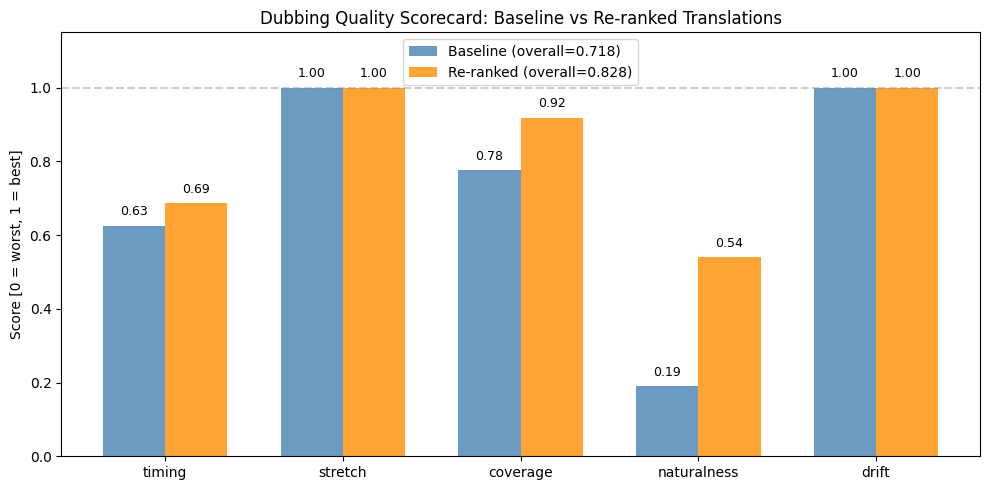

Saved to /home/gladw/foreign-whispers-GO/notebooks/alignment_integration/images/dubbing_scorecard.png


In [54]:
import matplotlib.pyplot as plt
import numpy as np

dimensions = ["timing", "stretch", "coverage", "naturalness", "drift"]
baseline_vals  = [baseline_score["timing_score"], baseline_score["stretch_score"],
                  baseline_score["coverage_score"], baseline_score["naturalness_score"],
                  baseline_score["drift_score"]]
reranked_vals  = [reranked_score["timing_score"], reranked_score["stretch_score"],
                  reranked_score["coverage_score"], reranked_score["naturalness_score"],
                  reranked_score["drift_score"]]

x = np.arange(len(dimensions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, baseline_vals,  width, label=f"Baseline (overall={baseline_score['overall']:.3f})",  color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, reranked_vals, width, label=f"Re-ranked (overall={reranked_score['overall']:.3f})", color="darkorange", alpha=0.8)

ax.set_ylabel("Score [0 = worst, 1 = best]")
ax.set_title("Dubbing Quality Scorecard: Baseline vs Re-ranked Translations")
ax.set_xticks(x)
ax.set_xticklabels(dimensions)
ax.set_ylim(0, 1.15)
ax.legend()
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.4)

# Label bars with values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(IMAGES_DIR / "dubbing_scorecard.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'dubbing_scorecard.png'}")

---

## Summary

Alignment is pure Python, no GPU required. All the timing analysis, policy decisions,
and global scheduling run on CPU with zero external dependencies beyond stdlib.

### Task overview

| Task | What you build | File to modify | Evaluation |
|------|---------------|----------------|------------|
| 1. Duration Prediction | Better TTS duration estimator | `alignment.py` — `_estimate_duration` | Mean absolute error vs ground truth |
| 2. Translation Re-ranking | Shorter candidates that fit the timing budget | `reranking.py` — `get_shorter_translations` | Segments moved from `REQUEST_SHORTER` to `ACCEPT` |
| 3. Global Optimizer | DP/ILP/search optimizer that beats greedy | `alignment.py` — new `global_align_dp` | Total drift, severe stretch count |
| 4. Quality Scorecard | Multi-dimensional evaluation framework | `evaluation.py` — new `dubbing_scorecard` | Dimension independence, cross-clip consistency |

Each task builds on the analysis you ran above and uses data already in `pipeline_data/`.
Validate your results end-to-end by re-running the TTS and stitch notebooks.

### Cross-notebook connections

- **Speaker-aware alignment** — the `diarization_integration` notebook labels speaker turns.
  Feed that signal into your optimizer to prevent borrowing silence across speaker boundaries.
- **Voice cloning** — the `tts_integration` notebook wires per-speaker voice selection.
  Combined with diarization, different speakers get different voices.
